In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

### Часть 1 — Доделываем семинар и получаем SNP

Исходные данные:

- ecoli_k12.fna — геном непатогенного лабораторного штамма K-12 (будет референсом)

- ecoli_o157.fna — геном патогенного штамма O157:H7 (будем сравнивать с референсом)

1) На семинаре мы запустили выравнивание этих геномов с помощью MUMmer

`nucmer --prefix=ecoli_full ../data/ecoli_k12.fna ../data/ecoli_o157.fna`

2) Теперь извлечем из этого выравнивания SNP

`show-snps -C -r ecoli_full.delta > ecoli_full_snps.txt`

3) Шапка полученного файла:

`head -20 ecoli_full_snps.txt`

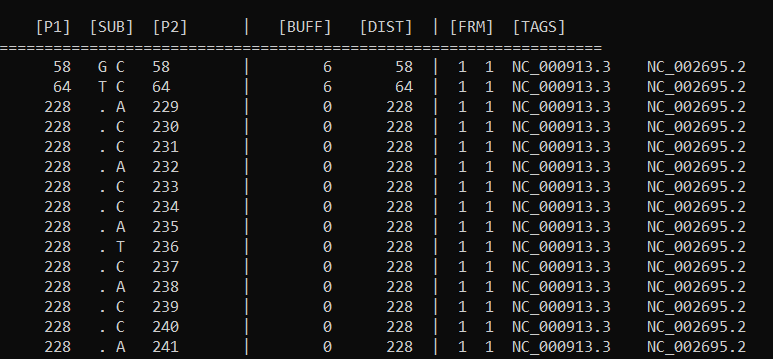

Пояснение значений полученных столбцов:

| Столбец | Обозначение | Описание |
|---|---|---|
| 1 | P1 | Позиция в референсном геноме (E. coli K-12, NC_000913.3) |
| 2 | SUB | Тип изменения |
| 3 | P2 | Позиция в геноме запроса (E. coli O157:H7, NC_002695.2) |
| 4-5 | BUFF, DIST | Технические параметры (буферная зона и расстояние до предыдущего SNP) |
| 6-7 | FRM | Фрейм и направление чтения (11 = прямая цепь) |
| 8-9 | TAGS | Идентификаторы референса (NC_000913.3) и запроса (NC_002695.2) |

Более подробное пояснение столбца SUB:

*SUB показывает букву в 1-м геноме (K-12) и букву во 2-м геноме (O157). Если нет буквы ставится точка*

Различные типы изменения:
- G C - замена буквы
- . A - инсерция (вставка) в O157
- T.  - делеция (удаление) в O157

4) Для дальнейшей работы удалим названия столбцов, оставив только чистые данные

`tail -n +6 ecoli_full_snps.txt > ecoli_snps_clean.txt`

### Часть 2 — Аннотация SNP

После того как мы нашли SNP между геномами K-12 и O157:H7, попробуем понять биологический смысл этих замен

Показатели, которые будем исследовать:

| Вопрос | Почему это важно |
|---|---|
| В каком гене находится | Мутация в важном гене может влиять на свойства бактерии |
| Тип SNP (синонимичный/несинонимичный) | Синонимичная → белок не меняется (скорее всего, не влияет). Несинонимичная → белок меняется (может изменить функцию) |
| Изменение аминокислоты | Некоторые замены критичны (например, в активном центре фермента) |
| Потенциальное функциональное значение | Оцениваем потенциальный вред (low/moderate/high) |

Выполнение:

1) Скачаем GenBank файл E. coli K-12

`cd ~/genome_alignment_prac/data`

`wget -O ecoli_k12.gbk "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.gbff.gz"`

`gunzip ecoli_k12.gbk.gz`

2) Напишем питон скрипт для обработки

`cd ~/genome_alignment_prac/scripts`

`nano annotate_snps.py`

Весь скрипт:

```
import pandas as pd
import matplotlib.pyplot as plt
from Bio import SeqIO
from Bio.Seq import Seq

# Таблица перевода аминокислот
AA = {'Ala':'A','Arg':'R','Asn':'N','Asp':'D','Cys':'C','Gln':'Q','Glu':'E',
      'Gly':'G','His':'H','Ile':'I','Leu':'L','Lys':'K','Met':'M','Phe':'F',
      'Pro':'P','Ser':'S','Thr':'T','Trp':'W','Tyr':'Y','Val':'V','Ter':'*'}

def one_letter(x): return AA.get(x.strip(), x[0] if x else '?')

snps = []
for line in open("../results/ecoli_snps_clean.txt"):
    p = line.strip().split()
    if len(p) >= 9 and p[0].isdigit():
        snps.append({'pos': int(p[0]), 'ref': p[1], 'alt': p[2]})
snps_df = pd.DataFrame(snps)
print(f"Загружено {len(snps_df)} SNP")

genes = []
for rec in SeqIO.parse("../data/ecoli_k12.gbk", "genbank"):
    for feat in rec.features:
        if feat.type == "CDS":
            genes.append({
                'name': feat.qualifiers.get('gene', [''])[0] or feat.qualifiers.get('locus_tag', [''])[0],
                'start': int(feat.location.start) + 1,
                'end': int(feat.location.end),
                'cds': str(feat.extract(rec.seq)),
                'product': feat.qualifiers.get('product', [''])[0]
            })
print(f"Загружено {len(genes)} генов")

def annotate_snp(pos, ref, alt):
    for g in genes:
        if g['start'] <= pos <= g['end']:
            idx = pos - g['start']
            cp = idx // 3
            if cp*3+3 <= len(g['cds']) and ref != '.' and alt != '.':
                codon = g['cds'][cp*3:cp*3+3]
                new_codon = list(codon)
                new_codon[idx % 3] = alt
                new_codon = ''.join(new_codon)
                old_aa = str(Seq(codon).translate())
                new_aa = str(Seq(new_codon).translate())
                if old_aa == new_aa:
                    return g['name'], 'synonymous', f'p.{one_letter(old_aa)}{cp+1}{one_letter(old_aa)}', 'low'
                else:
                    return g['name'], 'non-synonymous', f'p.{one_letter(old_aa)}{cp+1}{one_letter(new_aa)}', 'moderate'
            else:
                return g['name'], 'unknown', '', 'unknown'
    return 'intergenic', 'intergenic', '', 'low'

results = []
for _, s in snps_df.iterrows():
    gene, stype, aa_change, impact = annotate_snp(s['pos'], s['ref'], s['alt'])
    results.append({'pos': s['pos'], 'ref': s['ref'], 'alt': s['alt'], 
                    'gene': gene, 'type': stype, 'aa_change': aa_change, 
                    'functional_impact': impact})
res_df = pd.DataFrame(results)

print(f"Синонимичные: {len(res_df[res_df['type']=='synonymous'])}")
print(f"Несинонимичные: {len(res_df[res_df['type']=='non-synonymous'])}")
print(f"Межгенные: {len(res_df[res_df['type']=='intergenic'])}")

print("\nТоп 10 генов:")
coding = res_df[res_df['gene'] != 'intergenic']
top = coding.groupby('gene').size().sort_values(ascending=False).head(10)
for i, (g, c) in enumerate(top.items(), 1):
    prod = next((gx['product'][:50] for gx in genes if gx['name'] == g), '')
    print(f"{i}. {g}: {c} SNP | {prod}")

print("\nПримеры несинонимичных SNP:")
for _, r in res_df[res_df['type']=='non-synonymous'].head(5).iterrows():
    print(f"  {r['pos']}: {r['ref']}→{r['alt']} | {r['gene']} | {r['aa_change']} | {r['functional_impact']}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(res_df['pos'], bins=50, alpha=0.7)
ax1.set_xlabel('Позиция в геноме')
ax1.set_title('Распределение SNP')
types = res_df['type'].value_counts()
ax2.pie(types.values, labels=types.index, autopct='%1.1f%%')
ax2.set_title('Типы SNP')
plt.tight_layout()
plt.savefig('../results/snp_plots.png')

res_df.to_csv('../results/annotated_snps.csv', index=False)
print("\nСохранено: annotated_snps.csv и snp_plots.png")

```

Пояснение скрипта:

-  Создаём таблицу SNP, с которой будем работать дальше. Каждая строка — один SNP, содержащий:
   - pos — координата в геноме K-12
   - ref — буква в K-12 (или . если вставка)
   - alt — буква в O157 (или . если делеция)

- Загружаем гены из GenBank файла

  Используем библиотеку BioPython для чтения GenBank файла (.gbk). Перебираем все features в файле и ищем только те, у которых тип CDS 

Для каждого гена сохраняем:

- name — имя гена (например, gyrA, marR)
- start и end — координаты в геноме
- cds — последовательность ДНК гена
- product — описание белка
  
- Создаем функцию def annotate_snp:

```python
# 3.1 Перебираем все гены и проверяем, находится ли позиция SNP внутри координат гена
for g in genes:
    if g['start'] <= pos <= g['end']:
   
        # 3.2 Вычисляем позицию внутри гена
        idx = pos - g['start']

        # 3.3 Определяем номер кодона
        cp = idx // 3

        # 3.4 Проверяем, что SNP в пределах гена
        if cp*3+3 <= len(g['cds']) and ref != '.' and alt != '.':

            # 3.5 Извлекаем исходный кодон
            codon = g['cds'][cp*3:cp*3+3]

            # 3.6 Создаем мутантный кодон
            new_codon = list(codon)
            new_codon[idx % 3] = alt
            new_codon = ''.join(new_codon)

            # 3.7 Переводим в аминокислоты
            old_aa = str(Seq(codon).translate())
            new_aa = str(Seq(new_codon).translate())

            # 3.8 Определение типа SNP
            if old_aa == new_aa:
                return g['name'], 'synonymous', f'p.{one_letter(old_aa)}{cp+1}{one_letter(old_aa)}', 'low'
            else:
                return g['name'], 'non-synonymous', f'p.{one_letter(old_aa)}{cp+1}{one_letter(new_aa)}', 'moderate'

# Если SNP не попал ни в один ген, он считается межгенным

- Применяем функцию ко всем SNR

- Выводим статистику и строим графики

3. Запускаем скрипт и получаем результаты:

 `python annotate_snps.py`

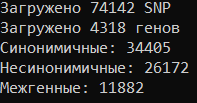

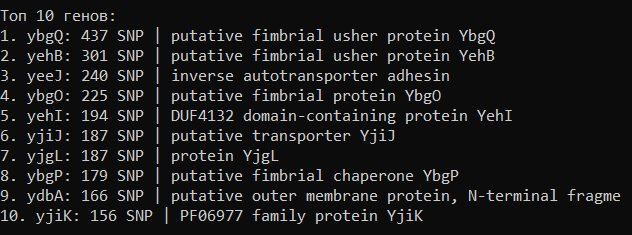

**Наблюдения и выводы**

Всего обнаружено примерно 74 000 SNP между штаммами K-12 и O157:H7, что соответствует ожидаемому уровню различий (~1.6% от генома).

Распределение типов SNP:
- Синонимичные замены (47.5%) - не меняют белок
- Несинонимичные замены (36.1%) - меняют структуру белка
- Межгенные SNP (16.4%) - могут влиять на регуляцию гено

Топ-10 генов с наибольшим количеством SNP включают:
- Гены, связанные с адгезией и вирулентностью (yehB, yeeJ, yehI)
- Гены наружной мембраны (ybgQ, ybgO)
- -Белки, участвующие в формировании биоплёнки (ydbA)

График плотности SNP с наложением позиций генов и диаграмма распределения типов SNP:

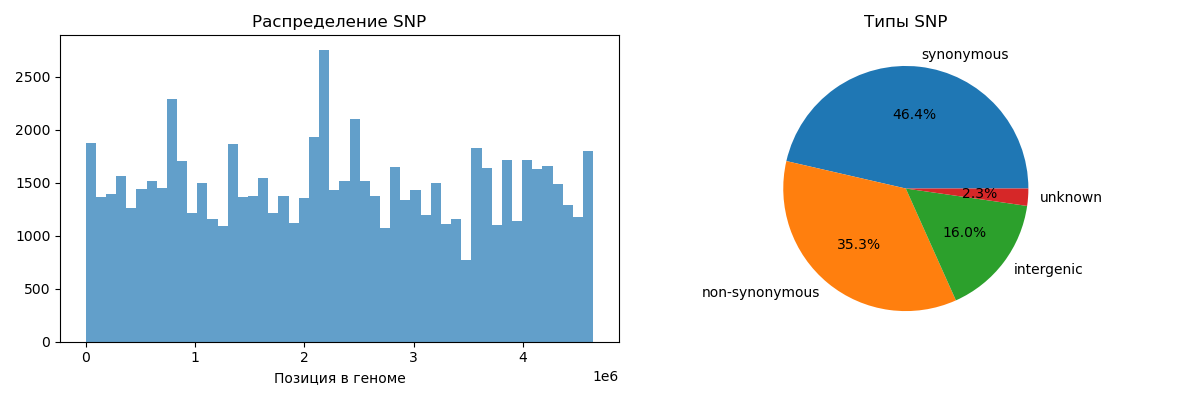

**Наблюдения и выводы**

График 1: Видим, что SNP распределены неравномерно - есть регионы с высокой плотностью  и регионы с низкой плотностью.

График 2:  Большинство SNP (46.4%) — синонимичные, не меняющие аминокислоту; 35.3% — несинонимичные, потенциально влияющие на функцию белков.


**Полученная таблица с результатами:**

In [121]:
df = pd.read_csv('annotated_snps.csv')
df.tail()

,pos,ref,alt,gene,type,aa_change,functional_impact
74137,4641411,C,T,yjtD,non-synonymous,p.T157I,moderate
74138,4641428,G,A,yjtD,non-synonymous,p.A163T,moderate
74139,4641439,T,C,yjtD,synonymous,p.D166D,low
74140,4641440,G,A,yjtD,non-synonymous,p.A167T,moderate
74141,4641488,A,G,yjtD,non-synonymous,p.T183A,moderate


### Часть 3 — Поиск функционально значимых SNP

Мы будем смотреть **идентификацию мутаций в генах устойчивости к антибиотикам**

Проведём проводился на основе аннотированных SNP в части 2  (`'annotated_snps.csv'`)

1. Отберём гены, ассоциированные с устойчивостью к антибиотикам, которые упоминаются в двух статьях, предложенных в задании:
- Carone et al. (2014) - https://pubmed.ncbi.nlm.nih.gov/24361397/ 
- Mir et al. (2020) https://pmc.ncbi.nlm.nih.gov/articles/PMC7178529/

Гены устойчивости из двух статей:

In [13]:
AR_GENES = {
    'marR': 'Carone 2014 - репрессор множественной устойчивости',
    'marA': 'Carone 2014 - активатор mar оперона',
    'marB': 'Carone 2014 - белок mar оперона',
    'acrA': 'Carone 2014 - эффлюкс-насос',
    'acrB': 'Carone 2014 / Mir 2020 - эффлюкс-насос',
    'tolC': 'Carone 2014 - внешнемембранный белок',
    'sul2': 'Mir 2020 - устойчивость к сульфизоксазолу',
    'tetB': 'Mir 2020 - устойчивость к тетрациклину',
    'aac(3)-IV': 'Mir 2020 - аминогликозиды',
    'int': 'Mir 2020 - интеграза',
    'mdtH': 'Mir 2020 - мультидраг-резистентность',
    'yjcP': 'Mir 2020 - эффлюкс-компонент',
    'yjcR': 'Mir 2020 - эффлюкс-компонент',
}

2. Отбираем SNR в этих генах:

In [140]:
ar_snps = df[df['gene'].isin(AR_GENES.keys())]
print(f"\nSNP в генах устойчивости: {len(ar_snps)}")

non_syn_ar = ar_snps[ar_snps['type'] == 'non-synonymous']
print(f"Несинонимичные: {len(non_syn_ar)}")


SNP в генах устойчивости: 95
Несинонимичные: 41


In [21]:
carone_genes = ['marR', 'marA', 'marB', 'acrA', 'acrB', 'tolC']
mir_genes = ['sul2', 'tetB', 'aac(3)-IV', 'int', 'mdtH', 'yjcP', 'yjcR']

carone_snps = ar_snps[ar_snps['gene'].isin(carone_genes)]
mir_snps = ar_snps[ar_snps['gene'].isin(mir_genes)]

print(f"Carone et al. (2014) гены: {len(carone_snps)} SNP, из них несинонимичных: {len(carone_snps[carone_snps['type']=='non-synonymous'])}")
print(f"Mir et al. (2020) гены: {len(mir_snps)} SNP, из них несинонимичных: {len(mir_snps[mir_snps['type']=='non-synonymous'])}")

Carone et al. (2014) гены: 78 SNP, из них несинонимичных: 29
Mir et al. (2020) гены: 17 SNP, из них несинонимичных: 12


**Итого**: Всего в генах устойчивости обнаружено 95 SNP, из которых 41 (43%) являются несинонимичными, то есть приводят к изменению аминокислотной последовательности белка.

3. Детальный анализ по генам

In [23]:
for gene in AR_GENES.keys():
    snps_in_gene = ar_snps[ar_snps['gene'] == gene]
    non_syn = snps_in_gene[snps_in_gene['type'] == 'non-synonymous']
    if len(snps_in_gene) > 0:
        print(f"\n{gene} ({AR_GENES[gene]}):")
        print(f"  Всего SNP: {len(snps_in_gene)}")
        print(f"  Несинонимичных: {len(non_syn)}")
        if len(non_syn) > 0:
            for _, row in non_syn.iterrows():
                print(f"    - {row['pos']}: {row['ref']}→{row['alt']} | {row['aa_change']}")


marR (Carone 2014 - репрессор множественной устойчивости):
  Всего SNP: 8
  Несинонимичных: 2
    - 1619426: G→A | p.G103S
    - 1619528: T→C | p.Y137H

marA (Carone 2014 - активатор mar оперона):
  Всего SNP: 3
  Несинонимичных: 0

marB (Carone 2014 - белок mar оперона):
  Всего SNP: 21
  Несинонимичных: 8
    - 1620002: C→T | p.S5L
    - 1620061: A→C | p.T25P
    - 1620062: C→A | p.T25K
    - 1620070: G→C | p.V28L
    - 1620086: C→G | p.A33G
    - 1620088: A→G | p.N34D
    - 1620120: C→A | p.H44Q
    - 1620198: C→A | p.H70Q

acrA (Carone 2014 - эффлюкс-насос):
  Всего SNP: 2
  Несинонимичных: 2
    - 484645: T→C | p.G74R
    - 484885: T→C | p.N154H

acrB (Carone 2014 / Mir 2020 - эффлюкс-насос):
  Всего SNP: 28
  Несинонимичных: 16
    - 481276: C→T | p.R8L
    - 481575: G→T | p.Q108*
    - 482487: G→A | p.V412M
    - 482643: T→C | p.G464R
    - 483006: G→A | p.E585K
    - 483009: A→T | p.R586C
    - 483012: A→C | p.T587P
    - 483147: A→C | p.K632Q
    - 483609: G→C | p.I786L
    -

In [25]:
marR_snps = ar_snps[ar_snps['gene'] == 'marR']
if len(marR_snps) > 0:
    print(f"Найдены мутации в marR: {len(marR_snps)}")
    for _, row in marR_snps.iterrows():
        print(f"  Позиция {row['pos']}: {row['ref']}→{row['alt']} | {row['aa_change']}")
else:
    print("Мутаций в marR не найдено")

Найдены мутации в marR: 8
  Позиция 1619200: C→T | p.R27R
  Позиция 1619305: G→A | p.K62K
  Позиция 1619308: A→G | p.V63V
  Позиция 1619371: G→A | p.V84V
  Позиция 1619395: C→T | p.D92D
  Позиция 1619426: G→A | p.G103S
  Позиция 1619479: C→T | p.H120H
  Позиция 1619528: T→C | p.Y137H


In [27]:
missing_genes_in_mir = ['blaTEM', 'qnrA', 'mcr-1', 'mph(A)']
for gene in missing_genes_in_mir:
    if gene in df['gene'].values:
        print(f"{gene}: НАЙДЕН в наших данных!")
    else:
        print(f"{gene}: не найден (как и в статье Mir)")

blaTEM: не найден (как и в статье Mir)
qnrA: не найден (как и в статье Mir)
mcr-1: не найден (как и в статье Mir)
mph(A): не найден (как и в статье Mir)


4. Сравним полученные результаты с статьями:

**Сравнение с Carone et al. (2014)**

В гене **marR**, который кодирует репрессор mar-оперона, обнаружены две несинонимичные замены: p.G103S и p.Y137H. Согласно статье, мутации в marR приводят к конститутивной активации marA и последующей сверхэкспрессии эффлюкс-насоса AcrAB-TolC, что даёт устойчивость к хлорамфениколу, тетрациклину и налидиксовой кислоте. В генах **acrA и acrB** обнаружено 18 несинонимичных SNP, включая стоп-кодон p.Q108* в acrB, который может полностью инактивировать белок.

**Сравнение с Mir et al. (2020)**

В полном соответствии с этой статьей, в нашем анализе **ген acrB** показал высокую вариабельность (28 SNP), а гены **blaTEM, qnrA, mcr-1 и mph(A)** отсутствуют у O157:H7. **Ген mdtH**, который в статье обнаружили у всех SS-O157 изолятов, в нашем анализе содержит 17 SNP, из которых 12 несинонимичных.


**Таким образом,** Наши данные полностью согласуются с результатами двух статей, подтверждая, что E. coli O157:H7 обладает повышенной мутабельностью в генах mar-регулона, но при этом не несёт клинически значимых AR-генов, таких как blaTEM или mcr-1

**Как это можно применить в жизни:**

- Обнаруженные мутации в генах marR и acrAB объясняют, почему O157:H7 может быстрее приобретать устойчивость к антибиотикам, чем K-12. Это важно для
прогнозирования рисков: если O157:H7 продолжит эволюционировать, он может стать устойчивым к антибиотикам, которые сейчас используются для лечения других инфекций

- Отсутствие генов blaTEM, mcr-1 и других клинически значимых маркеров устойчивости это хорошо, т.к означает что стандартные схемы лечения (поддерживающая терапия, а не антибиотики) остаются эффективными. Однако наличие стоп-кодона в acrB требует дальнейшего изучения, т.к инактивация эффлюкс-насоса может изменить профиль устойчивости

- Наши результаты показывают, что геном O157:H7 активно перестраивается (высокая вариабельность marB, acrB, mdtH). Это говорит о важности постоянного  мониторинга циркулирующих штаммов для своевременного выявления новых мутаций устойчивости